In [ ]:
"""
Momentum-based optimizers improve standard gradient descent by adding a momentum term that helps move more efficiently across the loss surface.

Momentum is inspired by physics, where movement depends on both current force and past velocity. In optimization, 
it helps smooth the learning process by incorporating past gradients, leading to faster and more stable convergence.
"""

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Objective Function

def objective_function(theta):
    """
    Rosenbrock function:
        f(x, y) = (1 - x)^2 + 100(y - x^2)^2

    The global minimum is at:
        (x, y) = (1, 1)
    """
    x, y = theta
    return (1 - x)**2 + 100 * (y - x**2)**2

In [3]:
# Gradient of the Objective Function

def gradient(theta):
    """
    Analytical gradient of the Rosenbrock function.
    """
    x, y = theta

    dx = -2 * (1 - x) - 400 * x * (y - x**2)
    dy = 200 * (y - x**2)

    return np.array([dx, dy])

In [4]:
# Standard Gradient Descent

def gradient_descent(
    objective,
    grad,
    initial_theta,
    learning_rate=0.001,
    iterations=3000
):
    """
    Standard Gradient Descent optimizer.
    """

    theta = np.array(initial_theta, dtype=float)

    theta_history = []
    loss_history = []

    for _ in range(iterations):

        # Save current state
        theta_history.append(theta.copy())
        loss_history.append(objective(theta))

        # Calculate gradient
        g = grad(theta)

        # Update parameters
        theta = theta - learning_rate * g

    return (
        theta,
        np.array(theta_history),
        np.array(loss_history)
    )


In [5]:
# Momentum-Based Gradient Descent

def momentum_gradient_descent(
    objective,
    grad,
    initial_theta,
    learning_rate=0.001,
    momentum=0.9,
    iterations=3000
):
    """
    Momentum-based Gradient Descent.

    velocity_t = momentum * velocity_(t-1) + gradient
    theta_t+1  = theta_t - learning_rate * velocity_t
    """

    theta = np.array(initial_theta, dtype=float)

    # Initialize velocity with zeros
    velocity = np.zeros_like(theta)

    theta_history = []
    loss_history = []

    for _ in range(iterations):

        # Save current state
        theta_history.append(theta.copy())
        loss_history.append(objective(theta))

        # Calculate gradient
        g = grad(theta)

        # Update velocity using momentum
        velocity = momentum * velocity + g

        # Update parameters
        theta = theta - learning_rate * velocity

    return (
        theta,
        np.array(theta_history),
        np.array(loss_history)
    )

In [6]:
# Run Both Optimizers

initial_theta = [-1.5, 1.5]

learning_rate = 0.001
momentum = 0.9
iterations = 3000


# Run standard Gradient Descent
gd_theta, gd_history, gd_loss = gradient_descent(
    objective=objective_function,
    grad=gradient,
    initial_theta=initial_theta,
    learning_rate=learning_rate,
    iterations=iterations
)


# Run Momentum Gradient Descent
momentum_theta, momentum_history, momentum_loss = (
    momentum_gradient_descent(
        objective=objective_function,
        grad=gradient,
        initial_theta=initial_theta,
        learning_rate=learning_rate,
        momentum=momentum,
        iterations=iterations
    )
)


In [7]:
# Print Results

print("=" * 60)
print("Optimization Results")
print("=" * 60)

print("\nInitial Point:")
print(initial_theta)

print("\nGradient Descent:")
print("Final parameters:", gd_theta)
print("Final loss:", objective_function(gd_theta))

print("\nMomentum Gradient Descent:")
print("Final parameters:", momentum_theta)
print("Final loss:", objective_function(momentum_theta))

print("\nTrue Global Minimum:")
print("[1, 1]")
print("Minimum value: 0")

Optimization Results

Initial Point:
[-1.5, 1.5]

Gradient Descent:
Final parameters: [0.81426712 0.66220203]
Final loss: 0.03456541168561656

Momentum Gradient Descent:
Final parameters: [0.99999877 0.99999753]
Final loss: 1.5162672164187362e-12

True Global Minimum:
[1, 1]
Minimum value: 0


In [8]:
# Create Contour Plot

x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)

X, Y = np.meshgrid(x, y)

Z = (1 - X)**2 + 100 * (Y - X**2)**2

levels = np.logspace(-1, 3.5, 30)

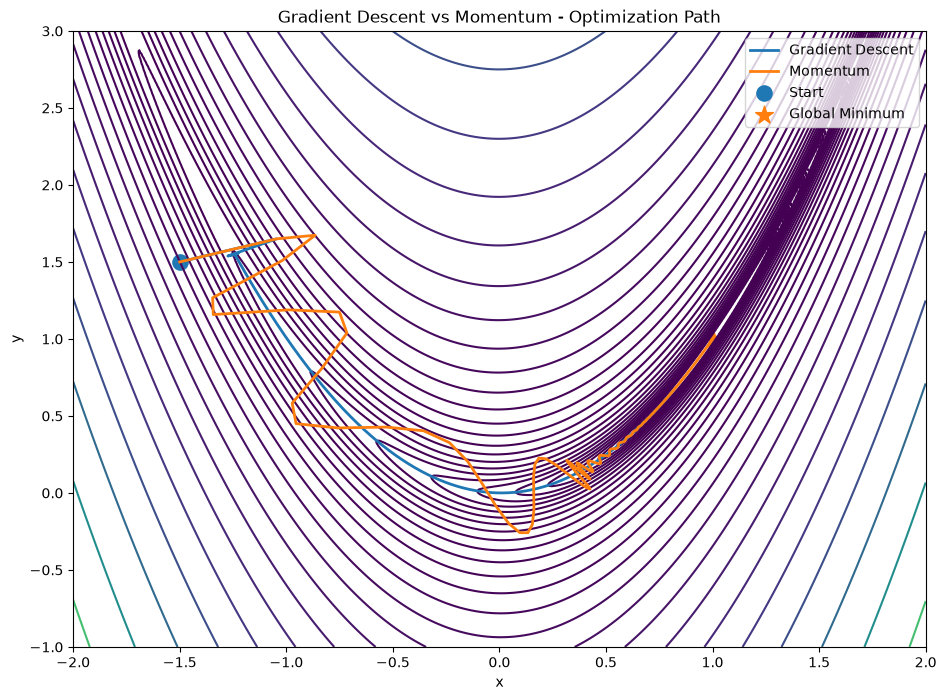

In [9]:
# Plot Optimization Paths

plt.figure(figsize=(11, 8))

# Draw contour lines of the objective function
plt.contour(
    X,
    Y,
    Z,
    levels=levels
)

# Gradient Descent path
plt.plot(
    gd_history[:, 0],
    gd_history[:, 1],
    linewidth=2,
    label="Gradient Descent"
)

# Momentum path
plt.plot(
    momentum_history[:, 0],
    momentum_history[:, 1],
    linewidth=2,
    label="Momentum"
)

# Starting point
plt.scatter(
    initial_theta[0],
    initial_theta[1],
    s=120,
    marker="o",
    label="Start"
)

# Global minimum
plt.scatter(
    1,
    1,
    s=180,
    marker="*",
    label="Global Minimum"
)

plt.xlabel("x")
plt.ylabel("y")

plt.title(
    "Gradient Descent vs Momentum - Optimization Path"
)

plt.legend()

plt.show()

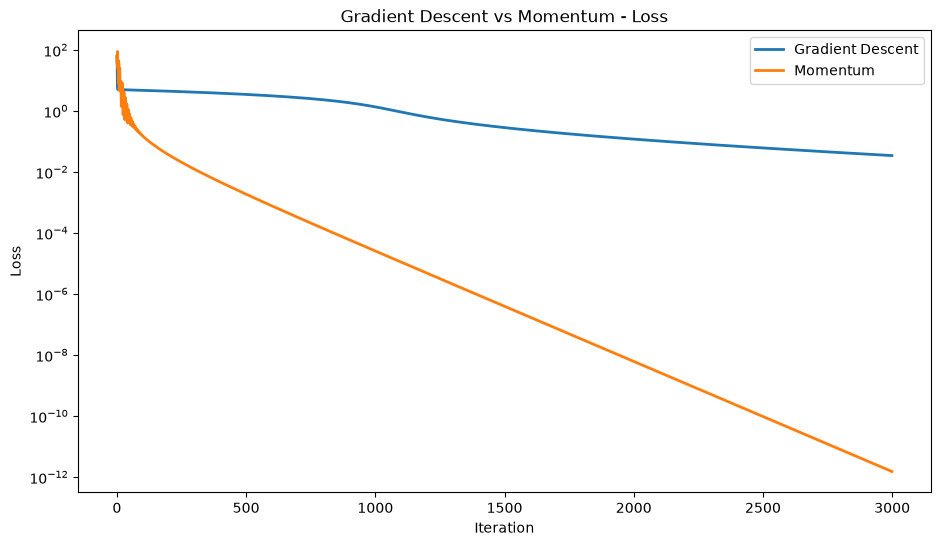

In [10]:
#  Plot Loss Curves

plt.figure(figsize=(11, 6))

plt.plot(
    gd_loss,
    label="Gradient Descent",
    linewidth=2
)

plt.plot(
    momentum_loss,
    label="Momentum",
    linewidth=2
)

# Log scale makes convergence easier to see
plt.yscale("log")

plt.xlabel("Iteration")
plt.ylabel("Loss")

plt.title(
    "Gradient Descent vs Momentum - Loss"
)

plt.legend()

plt.show()


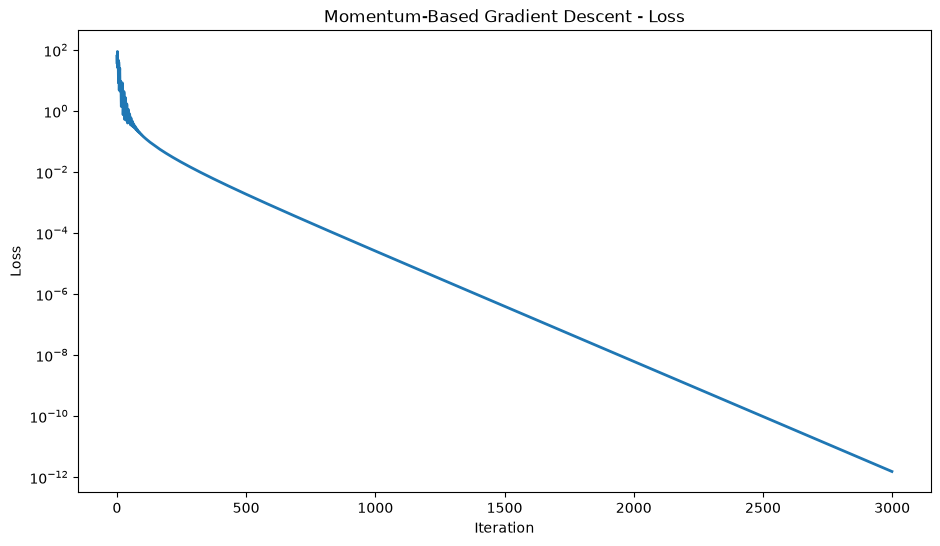

In [11]:
# Plot Momentum Loss Alone

plt.figure(figsize=(11, 6))

plt.plot(
    momentum_loss,
    linewidth=2
)

plt.yscale("log")

plt.xlabel("Iteration")
plt.ylabel("Loss")

plt.title(
    "Momentum-Based Gradient Descent - Loss"
)

plt.show()

In [12]:
# Simple Example: f(x) = x^2

def simple_function(x):
    return x**2


def simple_gradient(x):
    return 2 * x


def simple_momentum(
    initial_x,
    learning_rate=0.1,
    momentum=0.9,
    iterations=50
):
    """
    Simple one-dimensional Momentum optimizer.
    """

    x = float(initial_x)

    velocity = 0.0

    history = []

    for _ in range(iterations):

        # Save current position
        history.append(x)

        # Calculate gradient
        g = simple_gradient(x)

        # Update velocity
        velocity = momentum * velocity + g

        # Update x
        x = x - learning_rate * velocity

    return np.array(history)


# Run simple example
simple_history = simple_momentum(
    initial_x=10,
    learning_rate=0.1,
    momentum=0.9,
    iterations=50
)

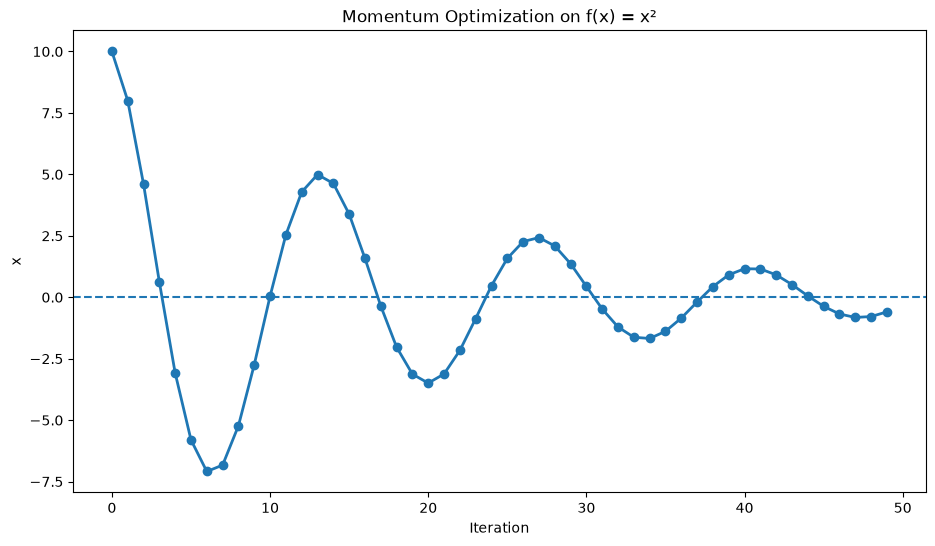

In [13]:
# Plot Simple Example

plt.figure(figsize=(11, 6))

plt.plot(
    simple_history,
    marker="o",
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Iteration")
plt.ylabel("x")

plt.title(
    "Momentum Optimization on f(x) = x²"
)

plt.show()


In [14]:
# Final Summary

print("=" * 60)
print("Momentum Algorithm Summary")
print("=" * 60)

print("""
At every iteration:

1. Calculate the gradient:
       g = gradient(theta)

2. Update velocity:
       velocity = momentum * velocity + g

3. Update parameters:
       theta = theta - learning_rate * velocity

The momentum term allows the optimizer to keep information
about the previous direction of movement.

This can make optimization faster and reduce oscillations.
""")

Momentum Algorithm Summary

At every iteration:

1. Calculate the gradient:
       g = gradient(theta)

2. Update velocity:
       velocity = momentum * velocity + g

3. Update parameters:
       theta = theta - learning_rate * velocity

The momentum term allows the optimizer to keep information
about the previous direction of movement.

This can make optimization faster and reduce oscillations.

